In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## fmri text

In [14]:
fmri = pd.read_csv('../../data/results/supplement/fmri_text.csv')
fmri = fmri.pivot(index='embed', columns='norm', values='r2_mean')
fmri = fmri.loc[['fMRI_text_cognival', 'fMRI_text_denoise_128d', 'fMRI_text_denoise_256d', 'fMRI_text_denoise_512d', 'fMRI_text_denoise_1024d']]
fmri

norm,aoa_glasgow,arousal_glasgow,concreteness_glasgow,dominance_glasgow,familiarity_glasgow,gender_association_glasgow,imageability_glasgow,semantic_size_glasgow,valence_glasgow
embed,,,,,,,,,
fMRI_text_cognival,-0.019051,-0.044966,-0.016066,-0.030578,-0.020753,-0.023693,-0.020584,-0.038038,-0.045542
fMRI_text_denoise_128d,-0.020800,-0.044686,0.016987,-0.035331,-0.030157,-0.026060,0.025236,-0.009469,-0.054036
fMRI_text_denoise_256d,-0.019359,-0.044300,-0.013855,-0.030513,-0.029341,-0.026146,-0.015677,-0.038761,-0.050247
fMRI_text_denoise_512d,-0.019178,-0.030602,0.007363,-0.040585,-0.029808,-0.026336,0.028134,-0.038750,-0.052029
fMRI_text_denoise_1024d,-0.019867,-0.030493,-0.023564,-0.033547,-0.042031,-0.053244,-0.026823,-0.026573,-0.054900


In [15]:
winner_mask = fmri.apply(lambda col: col == col.max(), axis=0)
winner_mask

norm,aoa_glasgow,arousal_glasgow,concreteness_glasgow,dominance_glasgow,familiarity_glasgow,gender_association_glasgow,imageability_glasgow,semantic_size_glasgow,valence_glasgow
embed,,,,,,,,,
fMRI_text_cognival,True,False,False,False,True,True,False,False,True
fMRI_text_denoise_128d,False,False,True,False,False,False,False,True,False
fMRI_text_denoise_256d,False,False,False,True,False,False,False,False,False
fMRI_text_denoise_512d,False,False,False,False,False,False,True,False,False
fMRI_text_denoise_1024d,False,True,False,False,False,False,False,False,False


Text(0.5, 1.0, 'Average Test ${R^2}$')

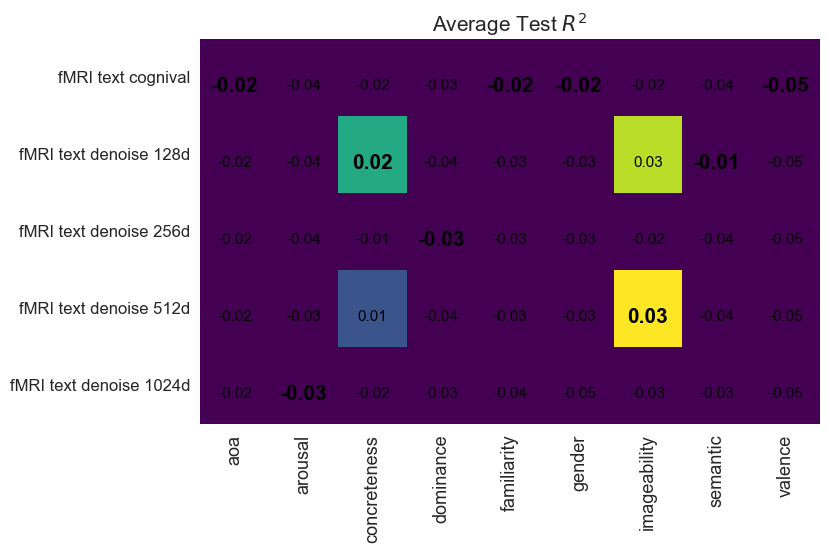

In [24]:
def annotate(df, ax):
    for x, norm_cat in enumerate(df.columns):
        for y, embed in enumerate(df.index):
            annot = df.loc[embed, norm_cat]

            # Scientific notation
            if abs(annot) > 1e3:
                annot = f'{annot:.1e}'
            elif np.isnan(annot):
                annot = ''
            else:
                annot = f'{annot:.2f}'

            # Fontsize and fontweight
            if winner_mask.loc[embed, norm_cat]:
                fontsize, fontweight = 15, 'bold'
            else:
                fontsize, fontweight = 11, 'normal'


            ax.text(
                x + .5, y + .6, annot, fontsize=fontsize, fontweight=fontweight,
                ha='center', va='center', color='black'
            )


fig, ax = plt.subplots(figsize=(8, 5))

vmax = fmri.max().max()
sns.heatmap(
    fmri, vmin=0, cmap='viridis',
    vmax=vmax, annot=False, fmt='', cbar=False, ax=ax
)
ax.set(xlabel='', xticklabels=[], ylabel='')


# Annotates cells
annotate(fmri, ax)

# y ticks
y_tick_labels = fmri.index.str.replace('_', ' ', regex=True)
ax.set_yticks(pd.Series(range(len(y_tick_labels))) + .5)
ax.set_yticklabels(y_tick_labels, fontsize=12)

# x ticks
x_tick_labels = fmri.columns.str.split('_').str[0]
ax.set_xticklabels(x_tick_labels, rotation=90, fontsize=13)

# Sets figure title
ax.set_title('Average Test ${R^2}$', fontsize=15)

## LLMs

In [ ]:
llms = pd.read_csv()